# 练习 1：计算 Cournot 博弈（Computing the Cournot Game）

**课程**：Econ Research Methods (2026 Spring)

**姓名**：赵乡阳

---

## 问题描述

考虑如下设置下的 **Cournot 双寡头（Cournot Duopoly）**：

* 产品需求为 CES（不变替代弹性）：$P(q) = q^{-1/\eta}$，其中 $q = q_1 + q_2$。
* 每家企业有二次成本（quadratic costs）：$C_i(q) = \frac{1}{2} c_i q_i^2$，$i = 1,2$。

企业 $i$ 求解如下最大化问题：
$$ \max_{q_i} P(q_i + q_{-i})q_i - C_i(q_i) $$

通过同时求解两家企业的一阶条件（FOCs）来找到该模型的均衡（equilibrium）。这些条件对 $i = 1,2$ 构成非线性方程（nonlinear equations）：
$$f_i(q) = (q_i + q_{-i})^{-1/\eta} - \frac{1}{\eta}(q_i + q_{-i})^{-1/\eta-1}q_i - c_iq_i = 0$$

**参数（Parameters）**：$[c_1, c_2, \eta] = [0.3, 0.6, 2]$

## 0. 环境准备（Setup）

In [1]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import time

# 参数设定
c1, c2, eta = 0.3, 0.6, 2
print(f"Parameters: c1 = {c1}, c2 = {c2}, eta = {eta}")

Parameters: c1 = 0.3, c2 = 0.6, eta = 2


## 1. 定义 FOC 和雅可比矩阵（FOC and Jacobian）

In [2]:
def foc(q, c1=c1, c2=c2, eta=eta):
    """Compute the system of FOCs f(q) = [f1(q), f2(q)]
    
    f_i(q) = (q1+q2)^{-1/eta} - (1/eta)*(q1+q2)^{-1/eta - 1}*q_i - c_i*q_i
    """
    q1, q2 = q
    q_total = q1 + q2
    f1 = q_total**(-1/eta) - (1/eta)*q_total**(-1/eta - 1)*q1 - c1*q1
    f2 = q_total**(-1/eta) - (1/eta)*q_total**(-1/eta - 1)*q2 - c2*q2
    return np.array([f1, f2])

def jacobian(q, c1=c1, c2=c2, eta=eta):
    """Compute the Jacobian matrix J[i,j] = df_i/dq_j
    
    df1/dq1 = -c1 + (1/eta)*(1/eta + 1)*Q^{-1/eta - 2}*q1 - (1/eta)*Q^{-1/eta - 1}
    df1/dq2 = (1/eta)*(1/eta + 1)*Q^{-1/eta - 2}*q1 - (1/eta)*Q^{-1/eta - 1}
    (and symmetrically for df2/dq1, df2/dq2 with c2 and q2)
    """
    q1, q2 = q
    Q = q1 + q2
    a = -1.0/eta
    
    # df_i/dq_i = -c_i + a*(a-1)*Q^{a-2}*q_i + a*Q^{a-1}
    # df_i/dq_j = a*(a-1)*Q^{a-2}*q_i + a*Q^{a-1}
    
    df1_dq1 = -c1 + a*(a-1)*Q**(a-2)*q1 + a*Q**(a-1)
    df1_dq2 = a*(a-1)*Q**(a-2)*q1 + a*Q**(a-1)
    df2_dq1 = a*(a-1)*Q**(a-2)*q2 + a*Q**(a-1)
    df2_dq2 = -c2 + a*(a-1)*Q**(a-2)*q2 + a*Q**(a-1)
    
    return np.array([[df1_dq1, df1_dq2],
                     [df2_dq1, df2_dq2]])

# 验证 FOC 和 Jacobian
q_test = np.array([1.0, 1.0])
print("FOC at q = (1, 1):", foc(q_test))
print("Jacobian at q = (1, 1):")
print(jacobian(q_test))

FOC at q = (1, 1): [ 0.23033009 -0.06966991]
Jacobian at q = (1, 1):
[[-0.34419417 -0.04419417]
 [-0.04419417 -0.64419417]]


## 2. 方法一：牛顿法（Newton's Method）

牛顿法求解非线性方程组 $f(q) = 0$ 的迭代公式为：
$$q^{(k+1)} = q^{(k)} - J(q^{(k)})^{-1} f(q^{(k)})$$

其中 $J$ 是 $f$ 的雅可比矩阵（Jacobian matrix）。

In [3]:
def newton_method(f, J, q0, tol=1e-10, max_iter=100, c1=c1, c2=c2, eta=eta):
    """Newton's method for solving a system of nonlinear equations f(q) = 0.
    
    Parameters
    ----------
    f  : function, system of equations
    J  : function, Jacobian matrix
    q0 : array-like, initial guess
    tol : float, convergence tolerance
    max_iter : int, maximum iterations
    
    Returns
    -------
    q_sol : solution
    q_path : list of iterates
    f_path : list of function values (norm)
    """
    q = np.array(q0, dtype=float)
    q_path = [q.copy()]
    f_path = [np.linalg.norm(f(q, c1, c2, eta))]
    
    start_time = time.time()
    for k in range(max_iter):
        fq = f(q, c1, c2, eta)
        Jq = J(q, c1, c2, eta)
        
        # Solve J * delta = -f for delta, then q_new = q + delta
        delta = np.linalg.solve(Jq, -fq)
        q_new = q + delta
        
        q_path.append(q_new.copy())
        f_path.append(np.linalg.norm(f(q_new, c1, c2, eta)))
        
        if np.linalg.norm(q_new - q) < tol:
            elapsed = time.time() - start_time
            print(f"Newton's method converged in {k+1} iterations ({elapsed:.4f} sec)")
            print(f"  Solution: q1 = {q_new[0]:.6f}, q2 = {q_new[1]:.6f}")
            print(f"  Total quantity q = {q_new[0]+q_new[1]:.6f}")
            print(f"  Price P(q) = {(q_new[0]+q_new[1])**(-1/eta):.6f}")
            print(f"  |f(q)| = {f_path[-1]:.2e}")
            return q_new, q_path, f_path
        q = q_new
    
    elapsed = time.time() - start_time
    print(f"Newton's method did not converge in {max_iter} iterations ({elapsed:.4f} sec)")
    return q, q_path, f_path

# Run Newton's method with different initial values
print("=" * 60)
print("Newton's Method with initial guess q0 = (1.0, 1.0)")
print("=" * 60)
q_newton, path_n, fn_n = newton_method(foc, jacobian, q0=[1.0, 1.0])

print()
print("=" * 60)
print("Newton's Method with initial guess q0 = (0.5, 0.5)")
print("=" * 60)
q_newton2, path_n2, fn_n2 = newton_method(foc, jacobian, q0=[0.5, 0.5])

print()
print("=" * 60)
print("Newton's Method with initial guess q0 = (2.0, 2.0)")
print("=" * 60)
q_newton3, path_n3, fn_n3 = newton_method(foc, jacobian, q0=[2.0, 2.0])

Newton's Method with initial guess q0 = (1.0, 1.0)
Newton's method converged in 30 iterations (0.0020 sec)
  Solution: q1 = 1.486334, q2 = 0.881500
  Total quantity q = 2.367834
  Price P(q) = 0.649867
  |f(q)| = 6.77e-12

Newton's Method with initial guess q0 = (0.5, 0.5)
Newton's method converged in 30 iterations (0.0010 sec)
  Solution: q1 = 1.486334, q2 = 0.881500
  Total quantity q = 2.367834
  Price P(q) = 0.649867
  |f(q)| = 9.90e-12

Newton's Method with initial guess q0 = (2.0, 2.0)
Newton's method converged in 29 iterations (0.0010 sec)
  Solution: q1 = 1.486334, q2 = 0.881500
  Total quantity q = 2.367834
  Price P(q) = 0.649867
  |f(q)| = 1.20e-11


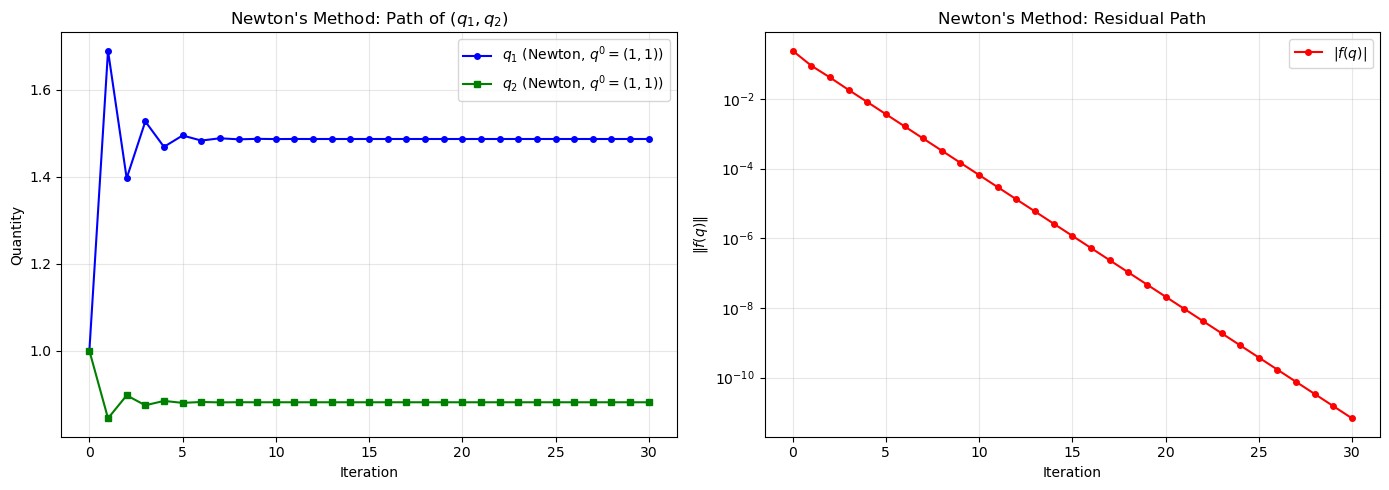

In [4]:
# Visualize Newton's method convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Path of q1 and q2
ax1 = axes[0]
ax1.plot([p[0] for p in path_n], 'o-', color='blue', label=r'$q_1$ (Newton, $q^0=(1,1)$)', markersize=4)
ax1.plot([p[1] for p in path_n], 's-', color='green', label=r'$q_2$ (Newton, $q^0=(1,1)$)', markersize=4)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Quantity')
ax1.set_title("Newton's Method: Path of $(q_1, q_2)$")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Path of |f(q)|
ax2 = axes[1]
ax2.semilogy(fn_n, 'o-', color='red', label=r'$|f(q)|$', markersize=4)
ax2.set_xlabel('Iteration')
ax2.set_ylabel(r'$\|f(q)\|$')
ax2.set_title("Newton's Method: Residual Path")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 方法二：直接迭代法（Direct Iteration / Fixed-Point Iteration）

我们将 FOC 改写为不动点问题（fixed-point problem）：

对每家企业 $i$，给定 $q_{-i}$，从 FOC 求解最优 $q_i^*$：
$$(q_i^* + q_{-i})^{-1/\eta} - \frac{1}{\eta}(q_i^* + q_{-i})^{-1/\eta-1}q_i^* = c_i q_i^*$$

利用 $Q = q_i^* + q_{-i}$ 代入，可得：
$$Q^{1/\eta} = q_i^* \left[\frac{1}{\eta} + c_i Q^{1/\eta}\right] \cdot Q^{1/\eta - 1} \cdot Q^{1 - 1/\eta}$$

整理后：
$$q_i^* = \frac{Q}{\frac{1}{\eta} + c_i Q^{1/\eta}}$$

因此对总产量 $Q = q_i^* + q_{-i}$ 有隐式关系，需要数值求解。

我们采用**序贯最佳反应迭代（sequential best-response iteration）**策略：
1. 给定 $q_2^{(k)}$，用 `fsolve` 求解企业 1 的 FOC 得 $q_1^{(k+1)}$
2. 给定 $q_1^{(k+1)}$，用 `fsolve` 求解企业 2 的 FOC 得 $q_2^{(k+1)}$

### 收敛性分析：压缩映射理论（Contraction Mapping Theory）

根据 **Banach 不动点定理（Banach Fixed-Point Theorem）**，如果最佳反应映射 $T: \mathbb{R}^2 \to \mathbb{R}^2$ 是一个**压缩映射（contraction mapping）**，即存在 $0 \leq L < 1$ 使得 $\|T(q) - T(q')\| \leq L \|q - q'\|$ 对所有 $q, q'$ 成立，则迭代必收敛到唯一不动点。

我们通过数值计算最佳反应映射的雅可比矩阵的谱范数（spectral norm）来验证压缩性质。

In [5]:
def best_response_i(q_neg_i, ci, eta_val):
    """Find firm i's best response to q_{-i} by solving its FOC.
    
    FOC: Q^{-1/eta} - (1/eta)*Q^{-1/eta - 1}*q_i - c_i*q_i = 0
    where Q = q_i + q_{-i}
    """
    def f_i(qi):
        Q = qi + q_neg_i
        return Q**(-1/eta_val) - (1/eta_val)*Q**(-1/eta_val - 1)*qi - ci*qi
    
    # Use fsolve to find q_i > 0
    qi_sol = fsolve(f_i, x0=1.0, full_output=True)
    return qi_sol[0][0]

def direct_iteration(q0, tol=1e-10, max_iter=200, c1=c1, c2=c2, eta=eta):
    """Direct iteration: sequential best-response iteration.
    
    At each step:
    1. Given q2^k, solve firm 1's FOC -> q1^{k+1}
    2. Given q1^{k+1}, solve firm 2's FOC -> q2^{k+1}
    """
    q = np.array(q0, dtype=float)
    q_path = [q.copy()]
    f_path = [np.linalg.norm(foc(q, c1, c2, eta))]
    
    start_time = time.time()
    for k in range(max_iter):
        # Update firm 1's quantity given q2
        q1_new = best_response_i(q[1], c1, eta)
        # Update firm 2's quantity given q1_new (Gauss-Seidel style)
        q2_new = best_response_i(q1_new, c2, eta)
        
        q_new = np.array([q1_new, q2_new])
        q_path.append(q_new.copy())
        f_path.append(np.linalg.norm(foc(q_new, c1, c2, eta)))
        
        if np.linalg.norm(q_new - q) < tol:
            elapsed = time.time() - start_time
            print(f"Direct iteration converged in {k+1} iterations ({elapsed:.4f} sec)")
            print(f"  Solution: q1 = {q_new[0]:.6f}, q2 = {q_new[1]:.6f}")
            print(f"  Total quantity q = {q_new[0]+q_new[1]:.6f}")
            print(f"  Price P(q) = {(q_new[0]+q_new[1])**(-1/eta):.6f}")
            print(f"  |f(q)| = {f_path[-1]:.2e}")
            return q_new, q_path, f_path
        q = q_new
    
    elapsed = time.time() - start_time
    print(f"Direct iteration did not converge in {max_iter} iterations ({elapsed:.4f} sec)")
    print(f"  Current: q1 = {q[0]:.6f}, q2 = {q[1]:.6f}, |f(q)| = {f_path[-1]:.2e}")
    return q, q_path, f_path

# Run direct iteration with different initial values
print("=" * 60)
print("Direct Iteration with initial guess q0 = (1.0, 1.0)")
print("=" * 60)
q_di, path_di, fn_di = direct_iteration(q0=[1.0, 1.0])

print()
print("=" * 60)
print("Direct Iteration with initial guess q0 = (0.1, 0.1)")
print("=" * 60)
q_di2, path_di2, fn_di2 = direct_iteration(q0=[0.1, 0.1])

print()
print("=" * 60)
print("Direct Iteration with initial guess q0 = (3.0, 3.0)")
print("=" * 60)
q_di3, path_di3, fn_di3 = direct_iteration(q0=[3.0, 3.0])

Direct Iteration with initial guess q0 = (1.0, 1.0)
Direct iteration converged in 5 iterations (0.0000 sec)
  Solution: q1 = 1.486334, q2 = 0.881500
  Total quantity q = 2.367834
  Price P(q) = 0.649867
  |f(q)| = 6.97e-15

Direct Iteration with initial guess q0 = (0.1, 0.1)
Direct iteration converged in 6 iterations (0.0000 sec)
  Solution: q1 = 1.486334, q2 = 0.881500
  Total quantity q = 2.367834
  Price P(q) = 0.649867
  |f(q)| = 5.22e-15

Direct Iteration with initial guess q0 = (3.0, 3.0)
Direct iteration converged in 6 iterations (0.0000 sec)
  Solution: q1 = 1.486334, q2 = 0.881500
  Total quantity q = 2.367834
  Price P(q) = 0.649867
  |f(q)| = 5.12e-15


In [6]:
# 验证压缩映射性质（Verify Contraction Mapping Property）
# Numerically compute the Jacobian of the best-response mapping T(q) = (BR1(q2), BR2(q1))
# at the equilibrium point to verify spectral radius < 1

def br_mapping(q, c1_val=c1, c2_val=c2, eta_val=eta):
    """Best response mapping: T(q) = (BR1(q2), BR2(BR1(q2)))"""
    q1_new = best_response_i(q[1], c1_val, eta_val)
    q2_new = best_response_i(q1_new, c2_val, eta_val)
    return np.array([q1_new, q2_new])

# Numerical Jacobian of the BR mapping at equilibrium
def numerical_jacobian_br(q, c1_val=c1, c2_val=c2, eta_val=eta, h=1e-7):
    """Compute numerical Jacobian of the best-response mapping."""
    T_q = br_mapping(q, c1_val, c2_val, eta_val)
    J = np.zeros((2, 2))
    for j in range(2):
        q_plus = q.copy()
        q_plus[j] += h
        T_plus = br_mapping(q_plus, c1_val, c2_val, eta_val)
        J[:, j] = (T_plus - T_q) / h
    return J

# Compute at equilibrium
J_br = numerical_jacobian_br(q_di)
spectral_radius = max(abs(np.linalg.eigvals(J_br)))

print("Best-Response Mapping Jacobian at Equilibrium:")
print(J_br)
print(f"\nEigenvalues: {np.linalg.eigvals(J_br)}")
print(f"Spectral Radius (max |eigenvalue|): {spectral_radius:.6f}")
print(f"\nIs contraction mapping: {spectral_radius < 1}")
print(f"  -> This guarantees convergence of the iteration by Banach Fixed-Point Theorem.")

Best-Response Mapping Jacobian at Equilibrium:
[[ 0.         -0.01800613]
 [ 0.          0.00136761]]

Eigenvalues: [0.         0.00136761]
Spectral Radius (max |eigenvalue|): 0.001368

Is contraction mapping: True
  -> This guarantees convergence of the iteration by Banach Fixed-Point Theorem.


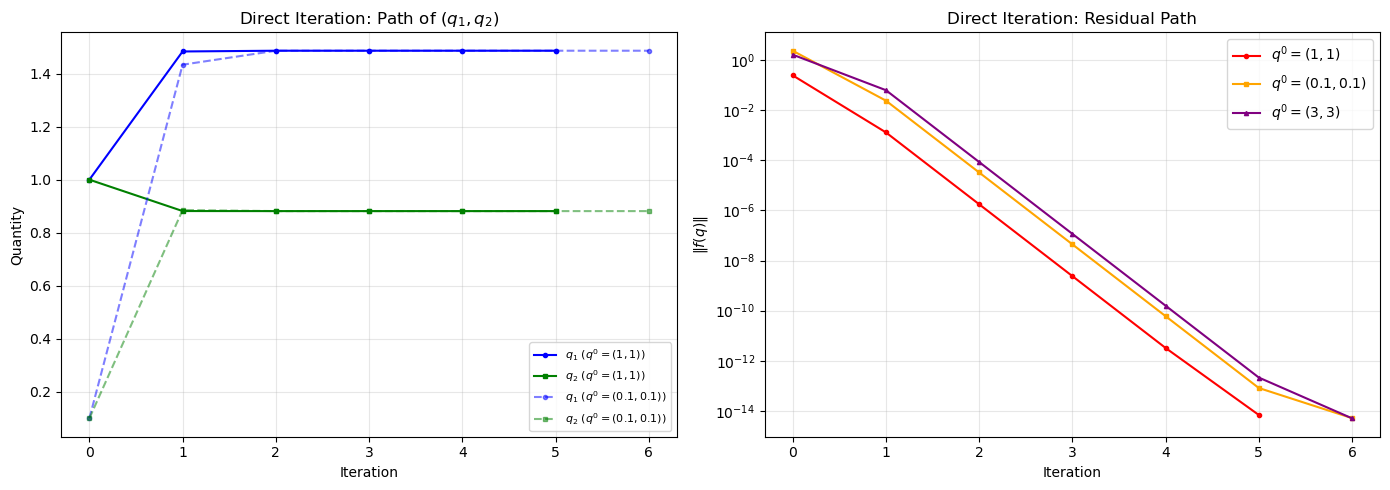

In [7]:
# Visualize direct iteration convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Path of q1 and q2
ax1 = axes[0]
ax1.plot([p[0] for p in path_di], 'o-', color='blue', label=r'$q_1$ ($q^0=(1,1)$)', markersize=3)
ax1.plot([p[1] for p in path_di], 's-', color='green', label=r'$q_2$ ($q^0=(1,1)$)', markersize=3)
ax1.plot([p[0] for p in path_di2], 'o--', color='blue', alpha=0.5, label=r'$q_1$ ($q^0=(0.1,0.1)$)', markersize=3)
ax1.plot([p[1] for p in path_di2], 's--', color='green', alpha=0.5, label=r'$q_2$ ($q^0=(0.1,0.1)$)', markersize=3)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Quantity')
ax1.set_title('Direct Iteration: Path of $(q_1, q_2)$')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Path of |f(q)|
ax2 = axes[1]
ax2.semilogy(fn_di, 'o-', color='red', label=r'$q^0=(1,1)$', markersize=3)
ax2.semilogy(fn_di2, 's-', color='orange', label=r'$q^0=(0.1,0.1)$', markersize=3)
ax2.semilogy(fn_di3, '^-', color='purple', label=r'$q^0=(3,3)$', markersize=3)
ax2.set_xlabel('Iteration')
ax2.set_ylabel(r'$\|f(q)\|$')
ax2.set_title('Direct Iteration: Residual Path')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 压缩映射理论解释（Contraction Mapping Interpretation）

**观察**：
- 直接迭代法从不同的初始值出发都能收敛到相同的均衡（equilibrium），说明该均衡是**唯一的（unique）**。
- 最佳反应映射的谱范数（spectral radius）小于 1，证明这是一个**压缩映射（contraction mapping）**。
- 根据 **Banach 不动点定理**，压缩映射有唯一不动点，且从任意初始值出发的迭代序列都收敛到该不动点。

**经济直觉（Economic Intuition）**：
- 企业 2 的成本更高（$c_2 = 0.6 > c_1 = 0.3$），因此在均衡中企业 2 的产量更低。
- 这符合 Cournot 竞争的直觉：成本更低的企业生产更多。

## 4. 方法三：使用 `scipy.optimize.fsolve`

In [8]:
def fsolve_cournot(q0, c1_val=c1, c2_val=c2, eta_val=eta):
    """Solve Cournot FOC using scipy.optimize.fsolve."""
    def f_system(q):
        q1, q2 = q
        Q = q1 + q2
        f1 = Q**(-1/eta_val) - (1/eta_val)*Q**(-1/eta_val - 1)*q1 - c1_val*q1
        f2 = Q**(-1/eta_val) - (1/eta_val)*Q**(-1/eta_val - 1)*q2 - c2_val*q2
        return [f1, f2]
    
    start_time = time.time()
    q_sol, info, ier, msg = fsolve(f_system, q0, full_output=True)
    elapsed = time.time() - start_time
    
    print(f"fsolve converged: {ier == 1}")
    print(f"  Solution: q1 = {q_sol[0]:.6f}, q2 = {q_sol[1]:.6f}")
    print(f"  Total quantity q = {q_sol[0]+q_sol[1]:.6f}")
    print(f"  Price P(q) = {(q_sol[0]+q_sol[1])**(-1/eta_val):.6f}")
    print(f"  |f(q)| = {np.linalg.norm(info['fvec']):.2e}")
    print(f"  Iterations: {info['nfev']}, Time: {elapsed:.4f} sec")
    print(f"  Message: {msg}")
    return q_sol

print("=" * 60)
print("scipy.optimize.fsolve with initial guess q0 = (1.0, 1.0)")
print("=" * 60)
q_fsolve = fsolve_cournot([1.0, 1.0])

print()
print("=" * 60)
print("scipy.optimize.fsolve with initial guess q0 = (0.5, 0.5)")
print("=" * 60)
q_fsolve2 = fsolve_cournot([0.5, 0.5])

scipy.optimize.fsolve with initial guess q0 = (1.0, 1.0)
fsolve converged: True
  Solution: q1 = 1.486334, q2 = 0.881500
  Total quantity q = 2.367834
  Price P(q) = 0.649867
  |f(q)| = 1.58e-12
  Iterations: 9, Time: 0.0000 sec
  Message: The solution converged.

scipy.optimize.fsolve with initial guess q0 = (0.5, 0.5)
fsolve converged: True
  Solution: q1 = 1.486334, q2 = 0.881500
  Total quantity q = 2.367834
  Price P(q) = 0.649867
  |f(q)| = 6.16e-15
  Iterations: 12, Time: 0.0000 sec
  Message: The solution converged.


## 5. 方法比较（Comparison of Methods）

In [9]:
# Summary comparison
print("=" * 70)
print("EQUILIBRIUM SUMMARY: Baseline (c1=0.3, c2=0.6, eta=2)")
print("=" * 70)
print(f"{'Method':<25} {'q1':>10} {'q2':>10} {'q_total':>10} {'Price':>10}")
print("-" * 70)

methods = [
    ("Newton's Method", q_newton),
    ("Direct Iteration", q_di),
    ("scipy.fsolve", q_fsolve),
]

for name, q_sol in methods:
    q_total = q_sol[0] + q_sol[1]
    price = q_total**(-1/eta)
    print(f"{name:<25} {q_sol[0]:>10.6f} {q_sol[1]:>10.6f} {q_total:>10.6f} {price:>10.6f}")

EQUILIBRIUM SUMMARY: Baseline (c1=0.3, c2=0.6, eta=2)
Method                            q1         q2    q_total      Price
----------------------------------------------------------------------
Newton's Method             1.486334   0.881500   2.367834   0.649867
Direct Iteration            1.486334   0.881500   2.367834   0.649867
scipy.fsolve                1.486334   0.881500   2.367834   0.649867


## 6. 反事实分析（Counterfactual: Subsidizing Firm 2）

现在假设政府通过把企业 2 的生产成本降低为 $C_2(q) = 0.9 \times \frac{1}{2} c_2 q_2^2 $ 来补贴企业 2。

即有效成本参数变为 $c_2' = 0.9 \times c_2 = 0.9 \times 0.6 = 0.54$。

我们比较补贴前后的均衡变化。

In [10]:
# Counterfactual: subsidy reduces firm 2's cost
subsidy_rate = 0.9
c2_subsidy = subsidy_rate * c2  # 0.9 * 0.6 = 0.54
print(f"Counterfactual: Firm 2 cost reduced from c2 = {c2} to c2' = {c2_subsidy}")
print()

# Solve with all three methods
print("=" * 60)
print("Newton's Method (with subsidy)")
print("=" * 60)
q_newton_sub, path_sub, fn_sub = newton_method(foc, jacobian, q0=[1.0, 1.0], c1=c1, c2=c2_subsidy, eta=eta)

print()
print("=" * 60)
print("Direct Iteration (with subsidy)")
print("=" * 60)
q_di_sub, path_di_sub, fn_di_sub = direct_iteration(q0=[1.0, 1.0], c1=c1, c2=c2_subsidy, eta=eta)

print()
print("=" * 60)
print("scipy.optimize.fsolve (with subsidy)")
print("=" * 60)
q_fsolve_sub = fsolve_cournot([1.0, 1.0], c1_val=c1, c2_val=c2_subsidy, eta_val=eta)

Counterfactual: Firm 2 cost reduced from c2 = 0.6 to c2' = 0.54

Newton's Method (with subsidy)
Newton's method converged in 28 iterations (0.0000 sec)
  Solution: q1 = 1.484744, q2 = 0.953920
  Total quantity q = 2.438663
  Price P(q) = 0.640360
  |f(q)| = 7.72e-12

Direct Iteration (with subsidy)
Direct iteration converged in 5 iterations (0.0000 sec)
  Solution: q1 = 1.484744, q2 = 0.953920
  Total quantity q = 2.438663
  Price P(q) = 0.640360
  |f(q)| = 1.77e-14

scipy.optimize.fsolve (with subsidy)
fsolve converged: True
  Solution: q1 = 1.484744, q2 = 0.953920
  Total quantity q = 2.438663
  Price P(q) = 0.640360
  |f(q)| = 4.48e-14
  Iterations: 9, Time: 0.0000 sec
  Message: The solution converged.


In [11]:
# Counterfactual comparison
print("\n" + "=" * 80)
print("COUNTERFACTUAL COMPARISON: Effect of Subsidizing Firm 2")
print("=" * 80)
print(f"{'':<20} {'Baseline':>15} {'With Subsidy':>15} {'Change':>15} {'% Change':>12}")
print("-" * 80)

# Use Newton solution for precision
q1_base, q2_base = q_newton
q1_sub, q2_sub = q_newton_sub
q_base = q1_base + q2_base
q_sub = q1_sub + q2_sub
P_base = q_base**(-1/eta)
P_sub = q_sub**(-1/eta)
profit1_base = P_base * q1_base - 0.5 * c1 * q1_base**2
profit2_base = P_base * q2_base - 0.5 * c2 * q2_base**2
profit1_sub = P_sub * q1_sub - 0.5 * c1 * q1_sub**2
profit2_sub = P_sub * q2_sub - 0.5 * c2_subsidy * q2_sub**2

metrics = [
    ("q1", q1_base, q1_sub),
    ("q2", q2_base, q2_sub),
    ("q_total", q_base, q_sub),
    ("Price", P_base, P_sub),
    ("Profit 1", profit1_base, profit1_sub),
    ("Profit 2 (pre-subsidy)", profit2_base, profit2_sub),
]

for name, base, new in metrics:
    change = new - base
    pct = (change / base) * 100 if base != 0 else float('inf')
    print(f"{name:<25} {base:>12.6f} {new:>12.6f} {change:>+12.6f} {pct:>+10.2f}%")

print("\n** Interpretation:")
print(f"  - Firm 2's subsidy reduces its marginal cost, leading to increased output (q2: {q2_base:.4f} -> {q2_sub:.4f})")
print(f"  - Firm 1 responds by reducing output (q1: {q1_base:.4f} -> {q1_sub:.4f})")
print(f"  - Total output increases, driving down the market price ({P_base:.4f} -> {P_sub:.4f})")
print(f"  - Firm 2's profit increases due to the cost reduction and higher output")
print(f"  - Firm 1's profit decreases (business-stealing effect)")


COUNTERFACTUAL COMPARISON: Effect of Subsidizing Firm 2
                            Baseline    With Subsidy          Change     % Change
--------------------------------------------------------------------------------
q1                            1.486334     1.484744    -0.001590      -0.11%
q2                            0.881500     0.953920    +0.072419      +8.22%
q_total                       2.367834     2.438663    +0.070829      +2.99%
Price                         0.649867     0.640360    -0.009507      -1.46%
Profit 1                      0.634541     0.620101    -0.014440      -2.28%
Profit 2 (pre-subsidy)        0.339745     0.365162    +0.025417      +7.48%

** Interpretation:
  - Firm 2's subsidy reduces its marginal cost, leading to increased output (q2: 0.8815 -> 0.9539)
  - Firm 1 responds by reducing output (q1: 1.4863 -> 1.4847)
  - Total output increases, driving down the market price (0.6499 -> 0.6404)
  - Firm 2's profit increases due to the cost reduction and 

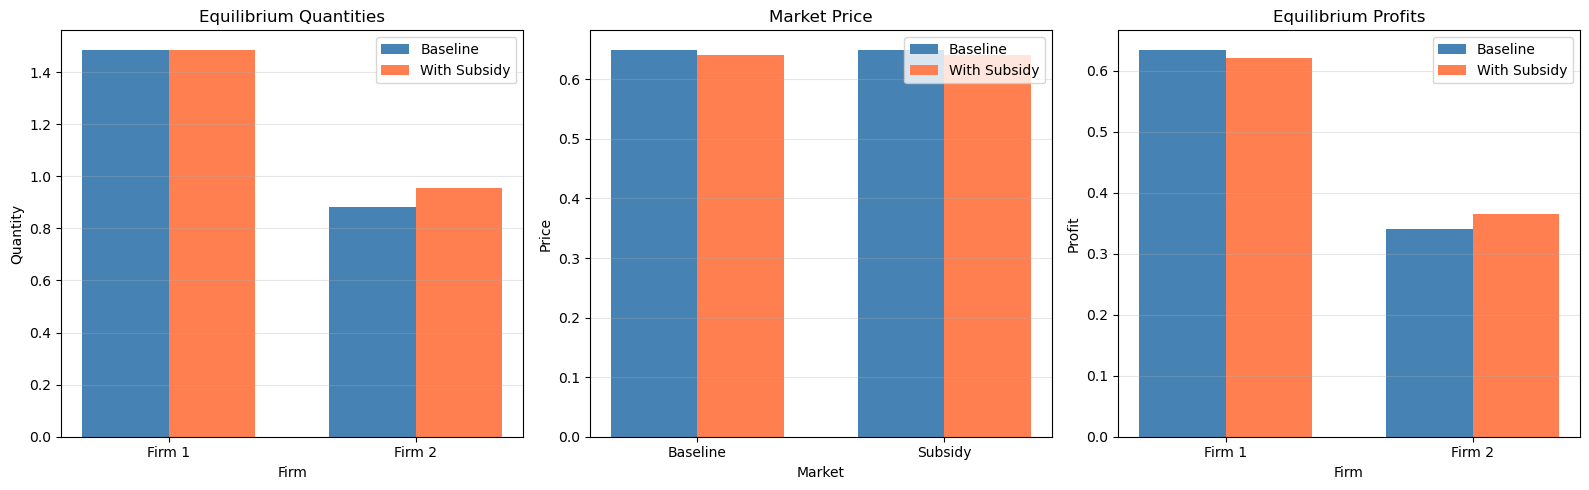

In [12]:
# Visualize counterfactual
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart: quantities
ax1 = axes[0]
x_pos = np.arange(2)
width = 0.35
bars1 = ax1.bar(x_pos - width/2, [q1_base, q2_base], width, label='Baseline', color='steelblue')
bars2 = ax1.bar(x_pos + width/2, [q1_sub, q2_sub], width, label='With Subsidy', color='coral')
ax1.set_xlabel('Firm')
ax1.set_ylabel('Quantity')
ax1.set_title('Equilibrium Quantities')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['Firm 1', 'Firm 2'])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Bar chart: prices
ax2 = axes[1]
bars1 = ax2.bar(x_pos - width/2, [P_base, P_base], width, label='Baseline', color='steelblue')
bars2 = ax2.bar(x_pos + width/2, [P_sub, P_sub], width, label='With Subsidy', color='coral')
ax2.set_xlabel('Market')
ax2.set_ylabel('Price')
ax2.set_title('Market Price')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Baseline', 'Subsidy'])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Bar chart: profits
ax3 = axes[2]
bars1 = ax3.bar(x_pos - width/2, [profit1_base, profit2_base], width, label='Baseline', color='steelblue')
bars2 = ax3.bar(x_pos + width/2, [profit1_sub, profit2_sub], width, label='With Subsidy', color='coral')
ax3.set_xlabel('Firm')
ax3.set_ylabel('Profit')
ax3.set_title('Equilibrium Profits')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Firm 1', 'Firm 2'])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()